In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-ev-charging-stations-dataset/detailed_ev_charging_stations.csv


# Display basic information about the dataset

In [2]:
df=pd.read_csv('/kaggle/input/global-ev-charging-stations-dataset/detailed_ev_charging_stations.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station ID                   5000 non-null   object 
 1   Latitude                     5000 non-null   float64
 2   Longitude                    5000 non-null   float64
 3   Address                      5000 non-null   object 
 4   Charger Type                 5000 non-null   object 
 5   Cost (USD/kWh)               5000 non-null   float64
 6   Availability                 5000 non-null   object 
 7   Distance to City (km)        5000 non-null   float64
 8   Usage Stats (avg users/day)  5000 non-null   int64  
 9   Station Operator             5000 non-null   object 
 10  Charging Capacity (kW)       5000 non-null   int64  
 11  Connector Types              5000 non-null   object 
 12  Installation Year            5000 non-null   int64  
 13  Renewable Energy S

# Display the first few rows of the dataset

In [3]:
df.head()

,Station ID,Latitude,Longitude,Address,Charger Type,Cost (USD/kWh),Availability,Distance to City (km),Usage Stats (avg users/day),Station Operator,Charging Capacity (kW),Connector Types,Installation Year,Renewable Energy Source,Reviews (Rating),Parking Spots,Maintenance Frequency
0,EVS00001,-33.400998,77.974972,"4826 Random Rd, City 98, Country",AC Level 2,0.27,9:00-18:00,4.95,35,EVgo,350,"CCS, CHAdeMO",2013,Yes,4.0,7,Annually
1,EVS00002,37.861857,-122.490299,"8970 San Francisco Ave, San Francisco",DC Fast Charger,0.19,24/7,4.96,83,EVgo,350,"Tesla, Type 2",2010,Yes,3.9,2,Monthly
2,EVS00003,13.776092,100.412776,"5974 Bangkok Ave, Bangkok",AC Level 2,0.48,6:00-22:00,8.54,24,ChargePoint,50,"Type 2, CCS",2019,No,3.6,9,Annually
3,EVS00004,43.628250,-79.468935,"6995 Toronto Ave, Toronto",AC Level 1,0.41,9:00-18:00,13.28,70,Greenlots,350,Type 2,2010,Yes,4.2,7,Monthly
4,EVS00005,19.119865,72.913368,"5704 Mumbai Ave, Mumbai",AC Level 2,0.11,9:00-18:00,9.76,19,EVgo,350,CCS,2015,Yes,3.7,6,Annually


# Basic statistics of numerical columns


In [4]:
df.describe()

,Latitude,Longitude,Cost (USD/kWh),Distance to City (km),Usage Stats (avg users/day),Charging Capacity (kW),Installation Year,Reviews (Rating),Parking Spots
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.942607,8.833487,0.300196,10.201810,55.453800,144.272000,2016.569400,3.994800,5.519600
std,32.315818,93.724046,0.115733,5.608316,26.494986,128.370674,4.004746,0.582667,2.874103
min,-89.680850,-178.870028,0.100000,0.500000,10.000000,22.000000,2010.000000,3.000000,1.000000
25%,13.758953,-87.680319,0.200000,5.430000,32.000000,50.000000,2013.000000,3.500000,3.000000
50%,34.029053,18.495233,0.300000,10.190000,56.000000,150.000000,2017.000000,4.000000,5.000000
75%,41.840249,100.454629,0.400000,14.902500,79.000000,350.000000,2020.000000,4.500000,8.000000
max,89.464534,179.664661,0.500000,20.000000,100.000000,350.000000,2023.000000,5.000000,10.000000


# Check for missing values


In [5]:
df.isnull().sum()

Station ID                     0
Latitude                       0
Longitude                      0
Address                        0
Charger Type                   0
Cost (USD/kWh)                 0
Availability                   0
Distance to City (km)          0
Usage Stats (avg users/day)    0
Station Operator               0
Charging Capacity (kW)         0
Connector Types                0
Installation Year              0
Renewable Energy Source        0
Reviews (Rating)               0
Parking Spots                  0
Maintenance Frequency          0
dtype: int64

# filling missing numeric values with median or mean


In [6]:
df['Cost (USD/kWh)'] = df['Cost (USD/kWh)'].fillna(df['Cost (USD/kWh)'].median())


# Visualizations

# 1. Distribution of Charging Capacity

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


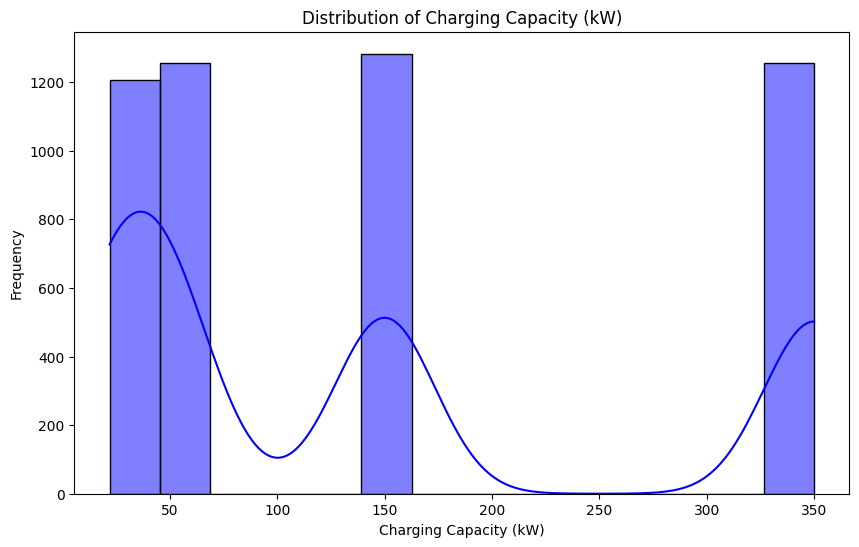

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Charging Capacity (kW)'], kde=True, color='blue')
plt.title('Distribution of Charging Capacity (kW)')
plt.xlabel('Charging Capacity (kW)')
plt.ylabel('Frequency')
plt.show()

# 2. Average Rating of Charging Stations by Operator


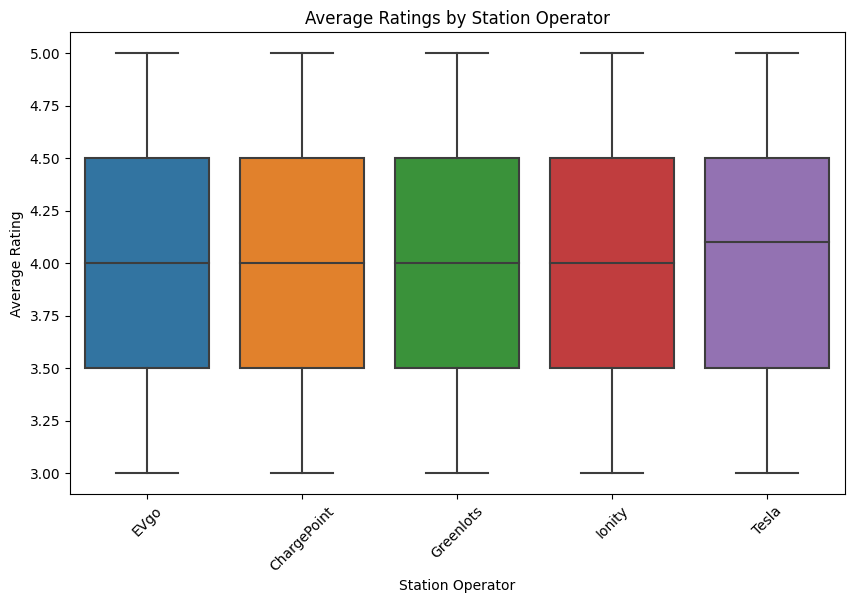

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Station Operator', y='Reviews (Rating)', data=df)
plt.title('Average Ratings by Station Operator')
plt.xlabel('Station Operator')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()


# 3. Heatmap of Correlation between Numerical Variables


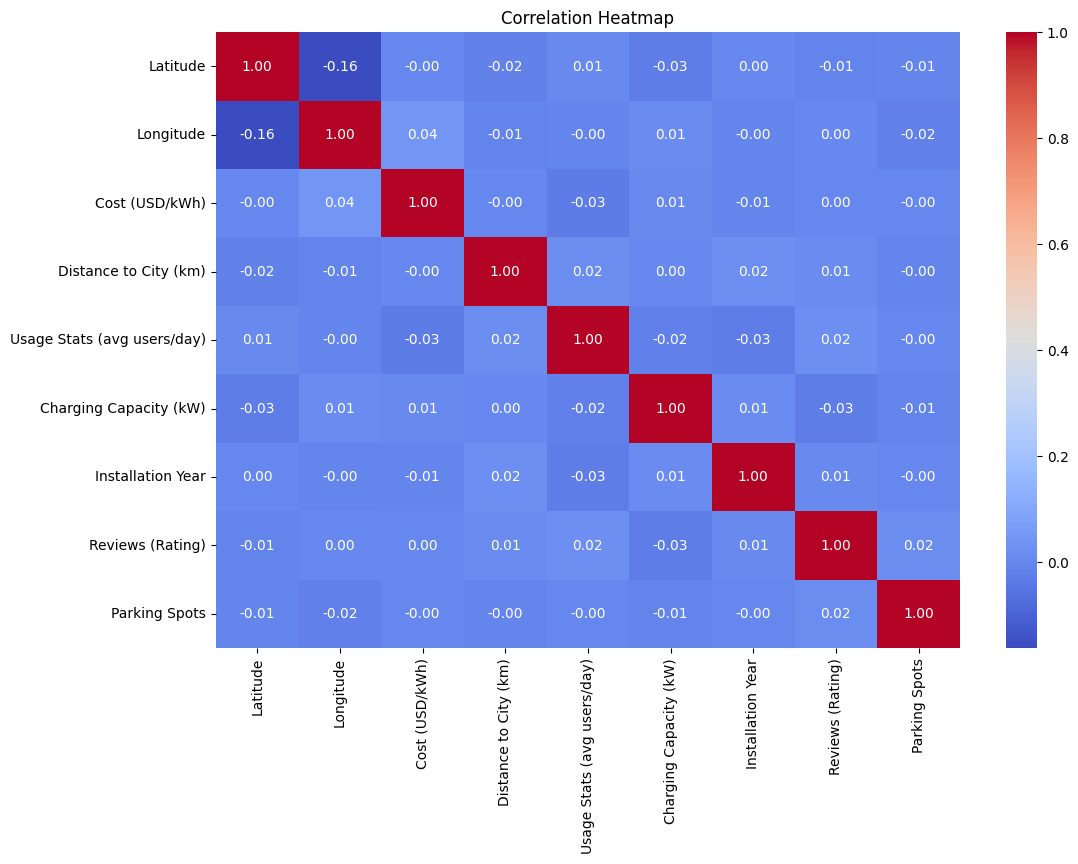

In [9]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 4. Charging Cost vs. Charging Capacity


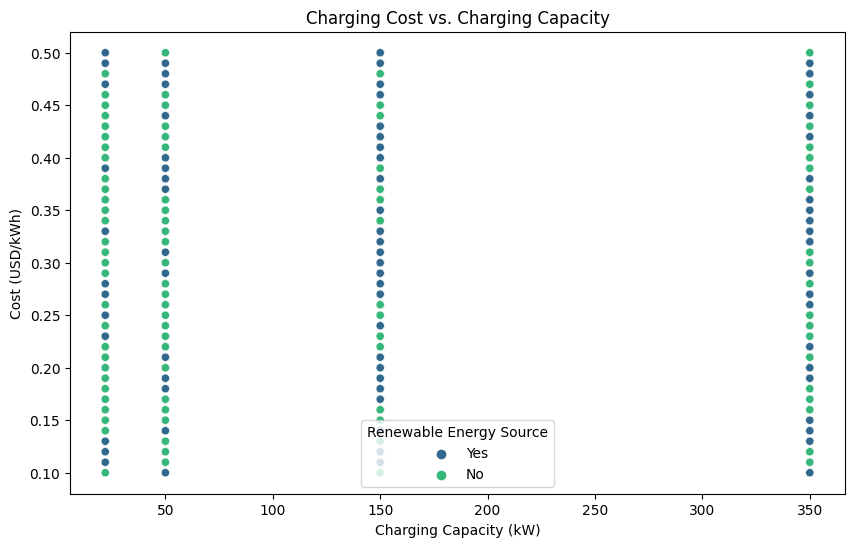

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Charging Capacity (kW)', y='Cost (USD/kWh)', data=df, hue='Renewable Energy Source', palette='viridis')
plt.title('Charging Cost vs. Charging Capacity')
plt.xlabel('Charging Capacity (kW)')
plt.ylabel('Cost (USD/kWh)')
plt.legend(title='Renewable Energy Source')
plt.show()


# 5. Number of Stations by Country 
\

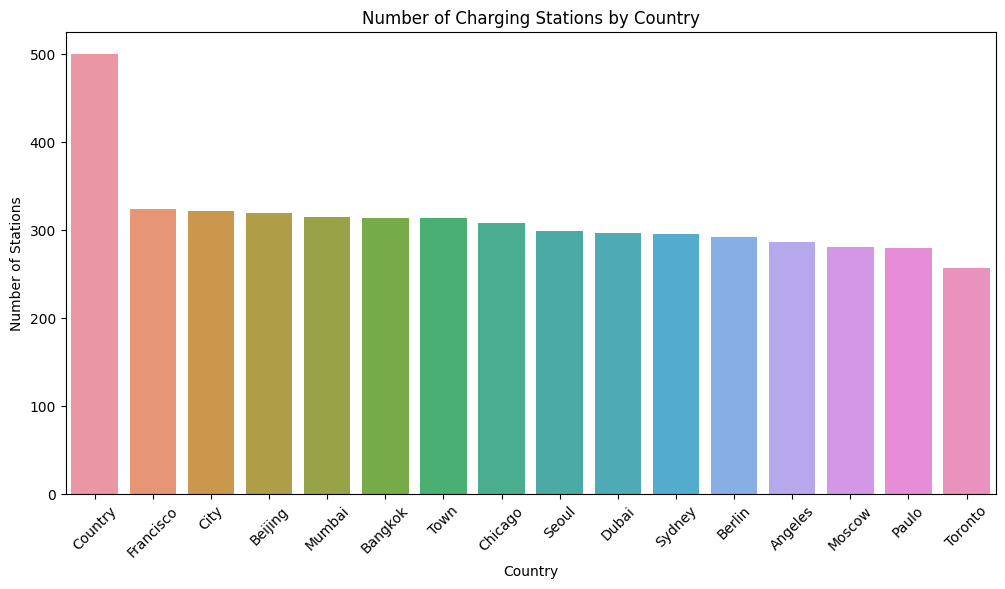

In [11]:

df['Country'] = df['Address'].apply(lambda x: x.split()[-1])  # Simplified extraction of country

plt.figure(figsize=(12, 6))
sns.countplot(x='Country', data=df, order=df['Country'].value_counts().index)
plt.title('Number of Charging Stations by Country')
plt.xlabel('Country')
plt.ylabel('Number of Stations')
plt.xticks(rotation=45)
plt.show()
